---
title: Project 2 — Sonar Mine vs Rock Classification
---

*Built with Grok Build*

Course: **EEE591 / EEE419 Python for Rapid Engineering Solutions**.

This project classifies **sonar returns** as rock vs mine using exploratory analysis,
standardization, PCA dimensionality reduction, and a multi-layer perceptron (MLP).
With `debug = True`, intermediate shapes and sample rows are printed.


In [1]:
##########################################################################################
# EEE591_419 Python for Rapid Engineering Solutions - Project 2: proj.py
# Mark Khusid
##########################################################################################

##########################################################################################
# Project 2 
##########################################################################################


### Import Libraries


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Set Debug State


In [3]:
debug = True
print(f'debug = {debug}')


debug = True


## Read Database


In [4]:
df = pd.read_csv("sonar_all_data_2.csv", header=None)


In [5]:
if debug:
    print(df.head(10))


       0       1       2       3       4       5       6       7       8   \
0  0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109   
1  0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
2  0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   
3  0.0100  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   
4  0.0762  0.0666  0.0481  0.0394  0.0590  0.0649  0.1209  0.2467  0.3564   
5  0.0286  0.0453  0.0277  0.0174  0.0384  0.0990  0.1201  0.1833  0.2105   
6  0.0317  0.0956  0.1321  0.1408  0.1674  0.1710  0.0731  0.1401  0.2083   
7  0.0519  0.0548  0.0842  0.0319  0.1158  0.0922  0.1027  0.0613  0.1465   
8  0.0223  0.0375  0.0484  0.0475  0.0647  0.0591  0.0753  0.0098  0.0684   
9  0.0164  0.0173  0.0347  0.0070  0.0187  0.0671  0.1056  0.0697  0.0962   

       9   ...      52      53      54      55      56      57      58  \
0  0.2111  ...  0.0065  0.0159  0.0072  0.0167  0.0180  0.0084  0.0090   
1  0

In [6]:
if debug:
    print(df.tail(10))


         0       1       2       3       4       5       6       7       8   \
198  0.0238  0.0318  0.0422  0.0399  0.0788  0.0766  0.0881  0.1143  0.1594   
199  0.0116  0.0744  0.0367  0.0225  0.0076  0.0545  0.1110  0.1069  0.1708   
200  0.0131  0.0387  0.0329  0.0078  0.0721  0.1341  0.1626  0.1902  0.2610   
201  0.0335  0.0258  0.0398  0.0570  0.0529  0.1091  0.1709  0.1684  0.1865   
202  0.0272  0.0378  0.0488  0.0848  0.1127  0.1103  0.1349  0.2337  0.3113   
203  0.0187  0.0346  0.0168  0.0177  0.0393  0.1630  0.2028  0.1694  0.2328   
204  0.0323  0.0101  0.0298  0.0564  0.0760  0.0958  0.0990  0.1018  0.1030   
205  0.0522  0.0437  0.0180  0.0292  0.0351  0.1171  0.1257  0.1178  0.1258   
206  0.0303  0.0353  0.0490  0.0608  0.0167  0.1354  0.1465  0.1123  0.1945   
207  0.0260  0.0363  0.0136  0.0272  0.0214  0.0338  0.0655  0.1400  0.1843   

         9   ...      52      53      54      55      56      57      58  \
198  0.2048  ...  0.0071  0.0084  0.0038  0.0026  0.00

## Separate Data into Features and Classes


In [7]:
X = df.iloc[:, :-2].values  # Last two columns are labels
y = df.iloc[:, -1].values # Use last column because it is numeric


## Exploratory Data Analysis on Database


### Find Number of Rows with Missing Data


In [8]:
if debug:
    print("Shape:", df.shape)
    print("\nMissing values:")
    print(df.isnull().sum())


Shape: (208, 62)

Missing values:
0     0
1     0
2     0
3     0
4     0
     ..
57    0
58    0
59    0
60    0
61    0
Length: 62, dtype: int64


### Descriptive Statistics Table of All Features


In [9]:
#df.describe()


In [10]:
#df.info()


### Create Box Plots of Features


In [11]:
# Remove the label columns (last 2 columns)
X_boxplots = df.iloc[:, :-2]

# Convert from wide format to long format
X_long = X_boxplots.melt(var_name="Feature", value_name="Value")

if debug:
    print(X_long[:20])
    print()
    print(X_long[-20:])


    Feature   Value
0         0  0.0200
1         0  0.0453
2         0  0.0262
3         0  0.0100
4         0  0.0762
5         0  0.0286
6         0  0.0317
7         0  0.0519
8         0  0.0223
9         0  0.0164
10        0  0.0039
11        0  0.0123
12        0  0.0079
13        0  0.0090
14        0  0.0124
15        0  0.0298
16        0  0.0352
17        0  0.0192
18        0  0.0270
19        0  0.0126

       Feature   Value
12460       59  0.0018
12461       59  0.0021
12462       59  0.0024
12463       59  0.0055
12464       59  0.0007
12465       59  0.0016
12466       59  0.0014
12467       59  0.0029
12468       59  0.0028
12469       59  0.0027
12470       59  0.0060
12471       59  0.0035
12472       59  0.0085
12473       59  0.0031
12474       59  0.0103
12475       59  0.0157
12476       59  0.0067
12477       59  0.0031
12478       59  0.0048
12479       59  0.0115


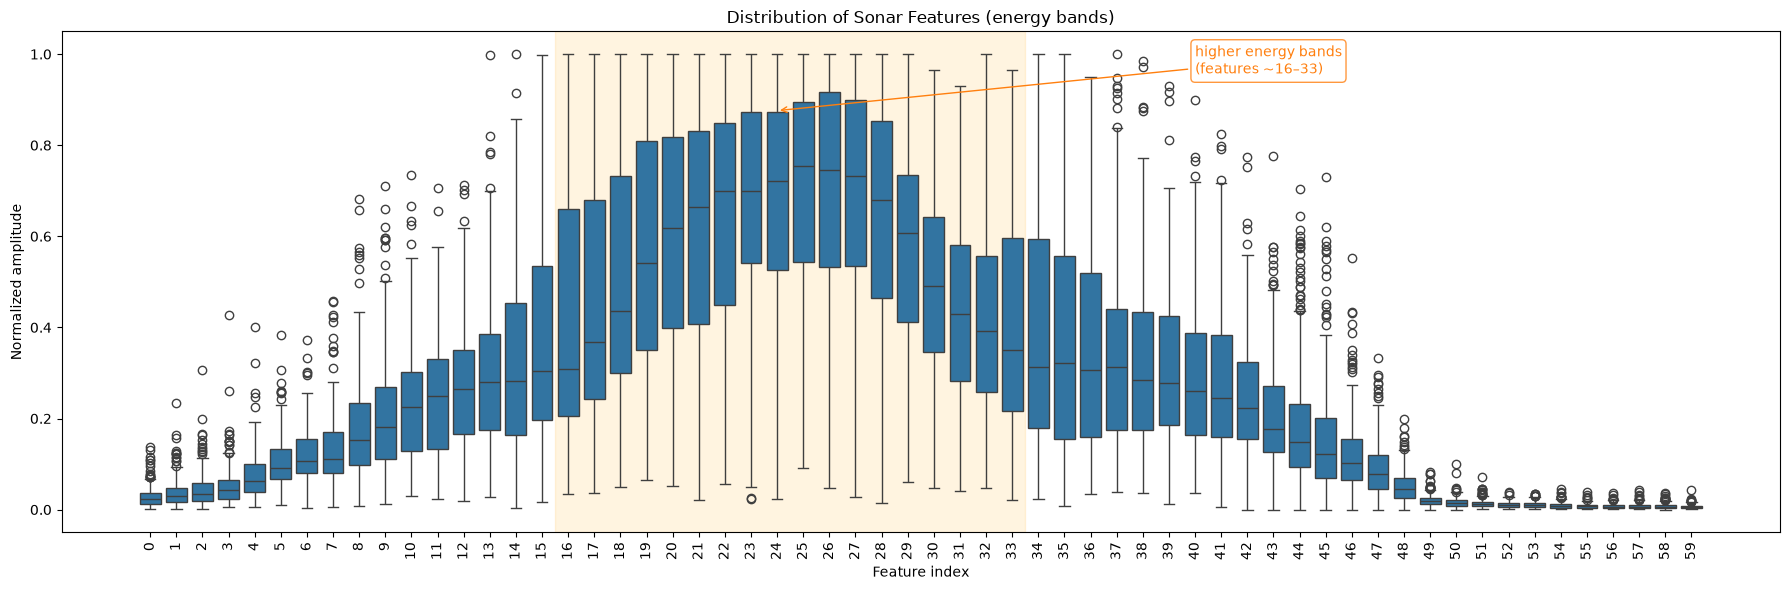

In [12]:
plt.figure(figsize=(18, 6))
sns.boxplot(data=X_long, x="Feature", y="Value")
plt.title("Distribution of Sonar Features (energy bands)")
plt.xlabel("Feature index")
plt.ylabel("Normalized amplitude")
plt.xticks(rotation=90)
plt.axvspan(15.5, 33.5, color="orange", alpha=0.12, zorder=0)
plt.annotate(
    "higher energy bands\n(features ~16–33)",
    xy=(24, float(X_long["Value"].quantile(0.95))),
    xytext=(40, float(X_long["Value"].quantile(0.98))),
    arrowprops=dict(arrowstyle="->", color="C1"),
    fontsize=10,
    color="C1",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor="C1"),
)
plt.tight_layout()
plt.show()


Most of the energy is in rows 16 to 33.  Data is range between 1 and 0.


### Create Histogram of Every Feature


In [13]:
# Feature columns only
X = df.iloc[:, :60]

if debug:
    print(X.iloc[:3])


       0       1       2       3       4       5       6       7       8   \
0  0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109   
1  0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
2  0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   

       9   ...      50      51      52      53      54      55      56  \
0  0.2111  ...  0.0232  0.0027  0.0065  0.0159  0.0072  0.0167  0.0180   
1  0.2872  ...  0.0125  0.0084  0.0089  0.0048  0.0094  0.0191  0.0140   
2  0.6194  ...  0.0033  0.0232  0.0166  0.0095  0.0180  0.0244  0.0316   

       57      58      59  
0  0.0084  0.0090  0.0032  
1  0.0049  0.0052  0.0044  
2  0.0164  0.0095  0.0078  

[3 rows x 60 columns]


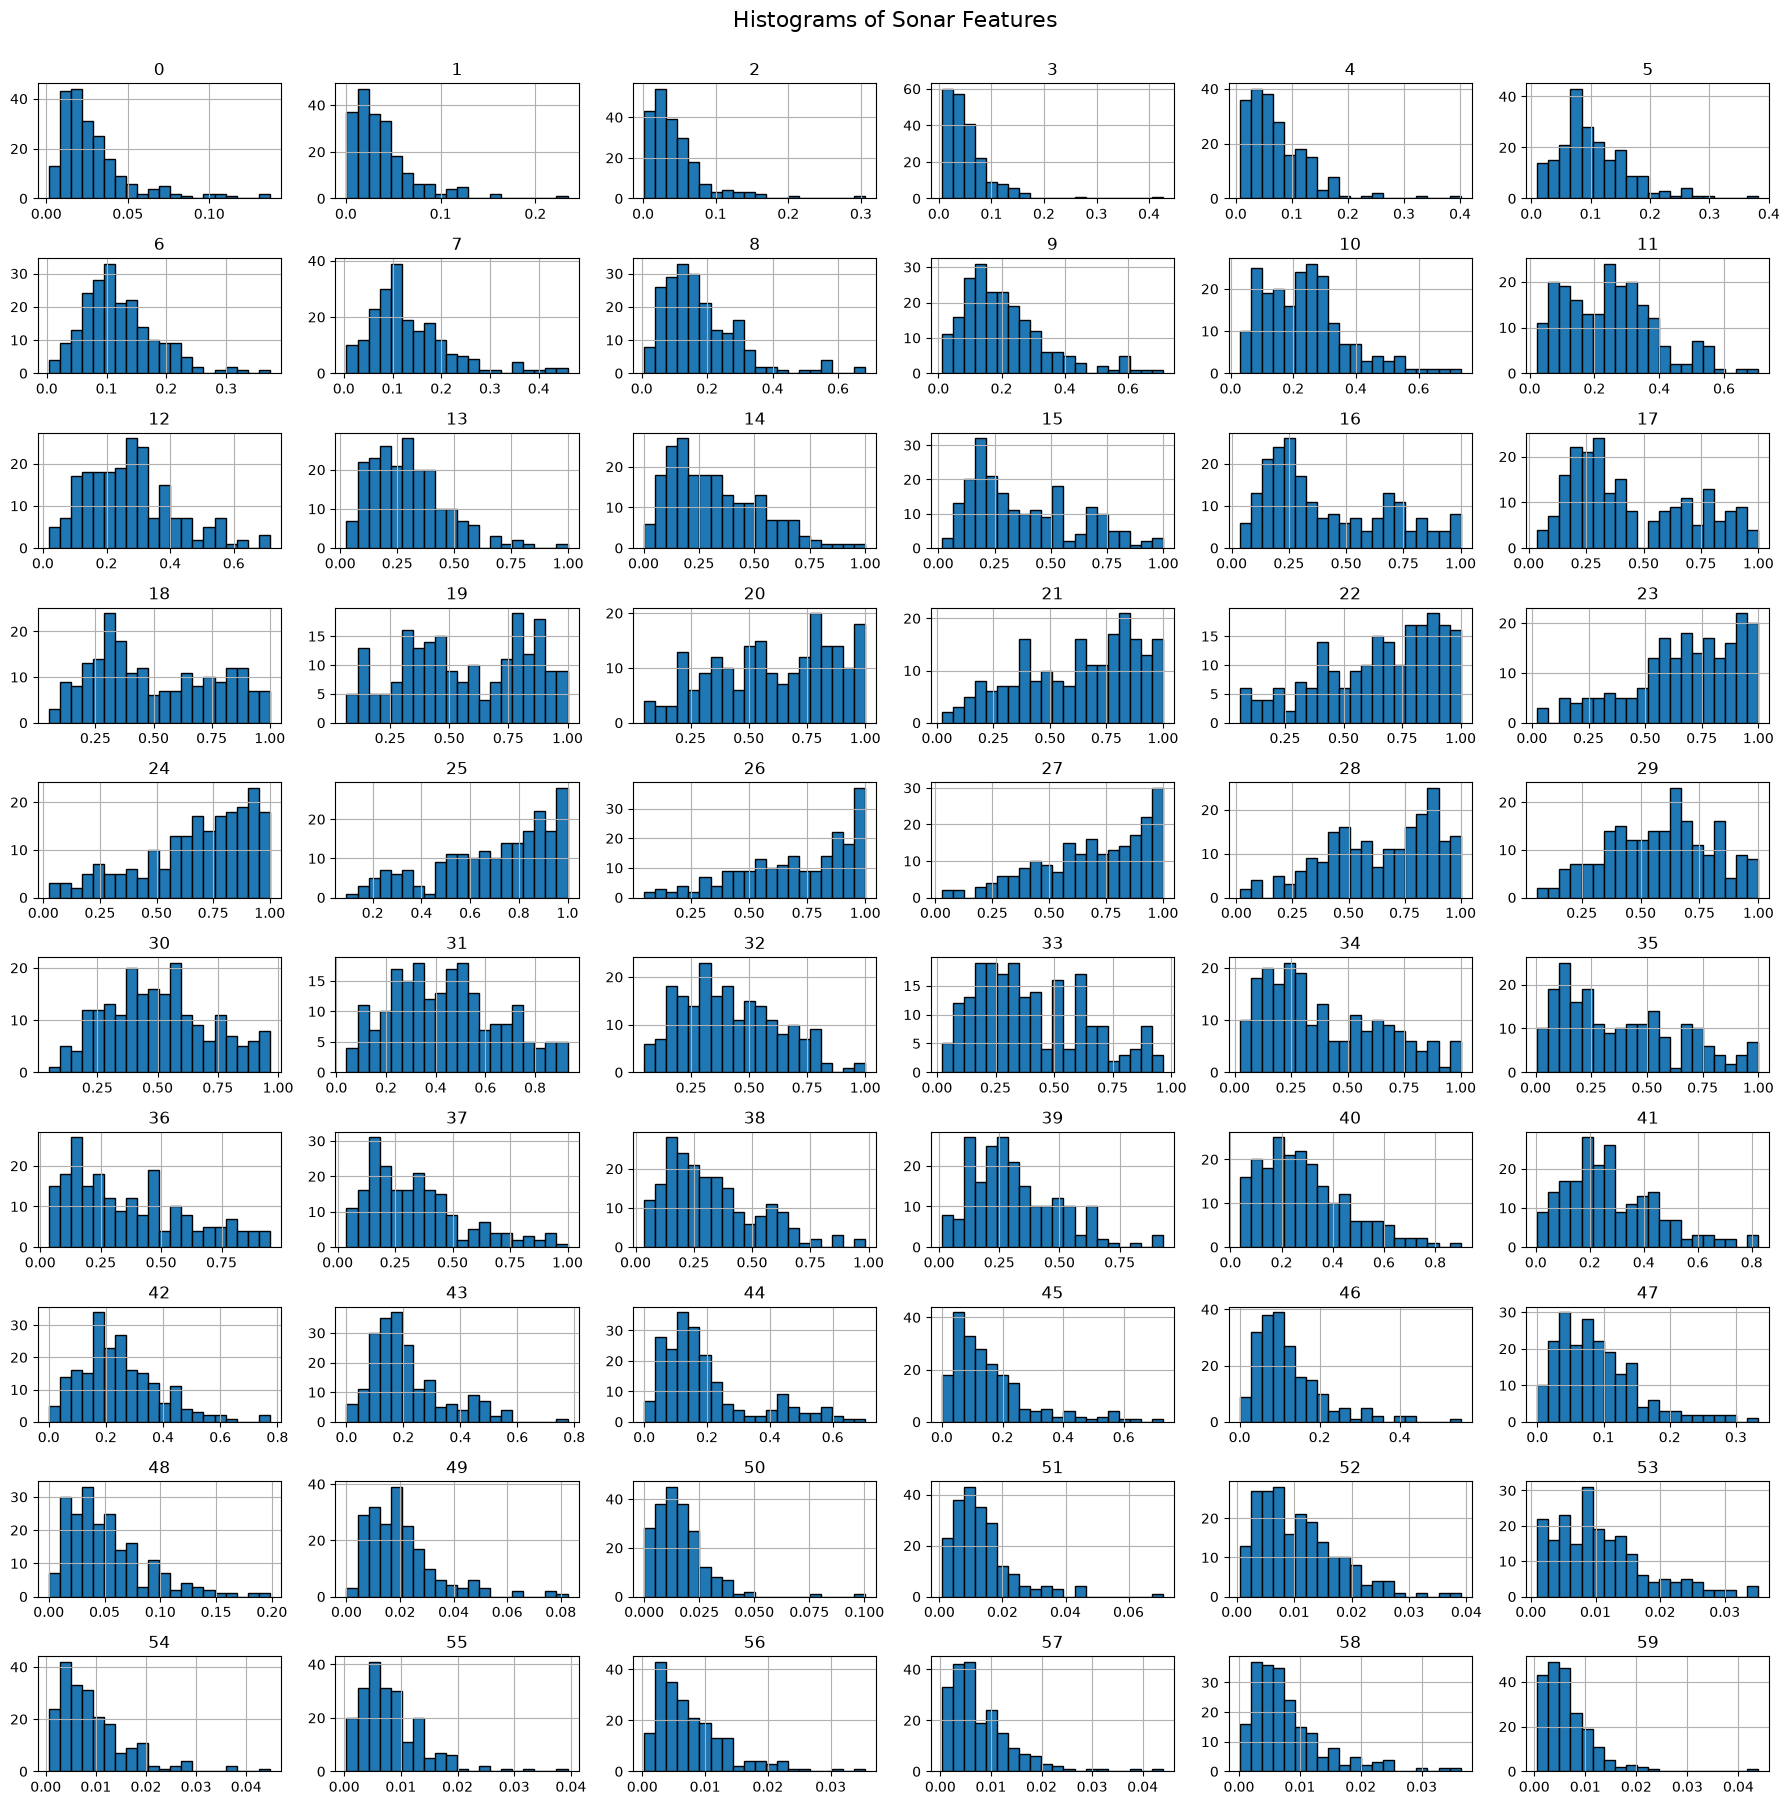

In [14]:
X.hist(
    bins=20,
    figsize=(18, 18),
    layout=(10, 6),   # 10 rows x 6 columns = 60 plots
    edgecolor='black'
)

plt.suptitle("Histograms of Sonar Features", fontsize=16, y=1.0)
plt.tight_layout()
plt.show()


Skewness varies along intervals.


### Create Heatmap of Every Feature


In [15]:
X_df = pd.DataFrame(X_boxplots)

if debug:
    print(X_df.iloc[:3])


       0       1       2       3       4       5       6       7       8   \
0  0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109   
1  0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
2  0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   

       9   ...      50      51      52      53      54      55      56  \
0  0.2111  ...  0.0232  0.0027  0.0065  0.0159  0.0072  0.0167  0.0180   
1  0.2872  ...  0.0125  0.0084  0.0089  0.0048  0.0094  0.0191  0.0140   
2  0.6194  ...  0.0033  0.0232  0.0166  0.0095  0.0180  0.0244  0.0316   

       57      58      59  
0  0.0084  0.0090  0.0032  
1  0.0049  0.0052  0.0044  
2  0.0164  0.0095  0.0078  

[3 rows x 60 columns]


       0       1       2       3       4       5       6       7       8   \
0  0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109   
1  0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
2  0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   

       9   ...      50      51      52      53      54      55      56  \
0  0.2111  ...  0.0232  0.0027  0.0065  0.0159  0.0072  0.0167  0.0180   
1  0.2872  ...  0.0125  0.0084  0.0089  0.0048  0.0094  0.0191  0.0140   
2  0.6194  ...  0.0033  0.0232  0.0166  0.0095  0.0180  0.0244  0.0316   

       57      58      59  
0  0.0084  0.0090  0.0032  
1  0.0049  0.0052  0.0044  
2  0.0164  0.0095  0.0078  

[3 rows x 60 columns]


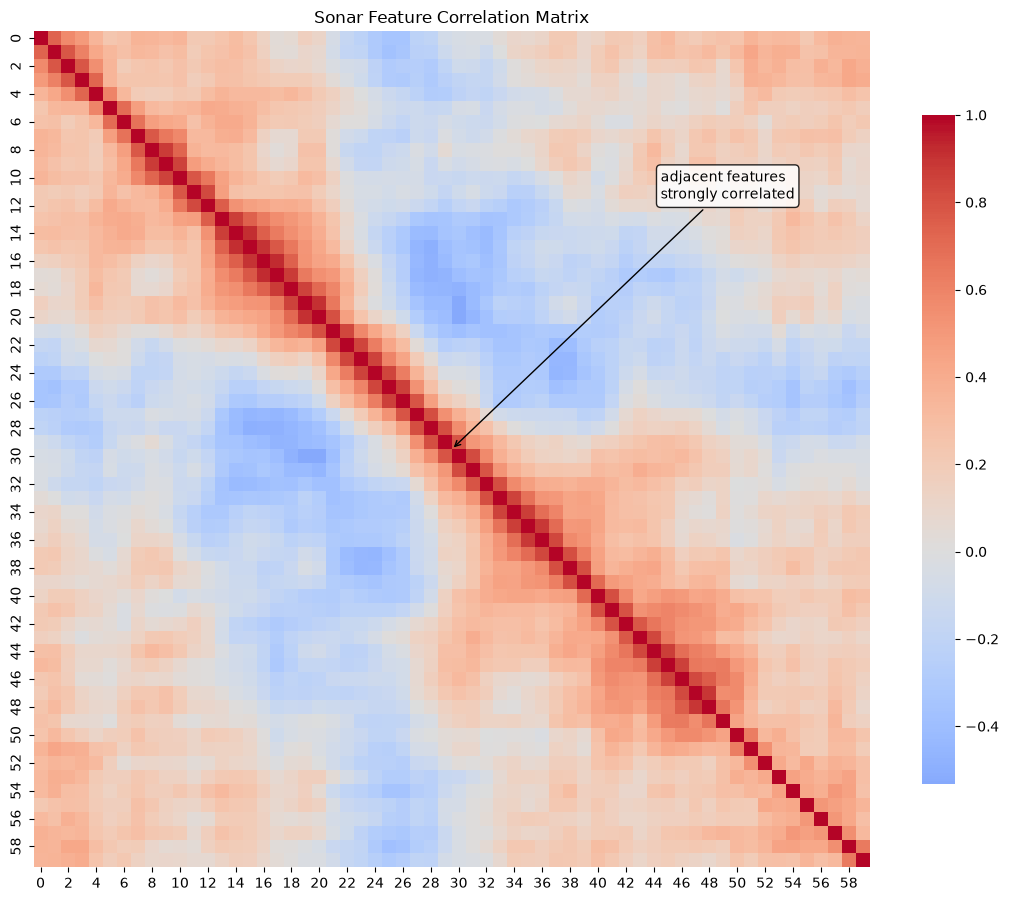

In [16]:
X_df = pd.DataFrame(X_boxplots)

if debug:
    print(X_df.iloc[:3])

corr = X_df.corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Sonar Feature Correlation Matrix")
plt.annotate(
    "adjacent features\nstrongly correlated",
    xy=(30, 30),
    xytext=(45, 12),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85),
)
plt.tight_layout()
plt.show()


Strong adjacent correlations


### Examine Class Label Distribution


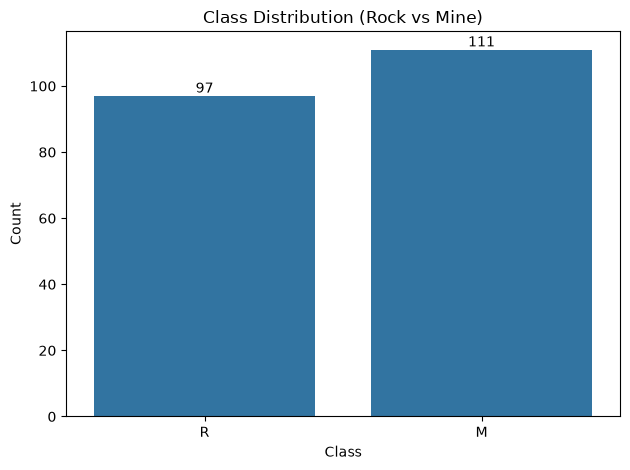

61
M    111
R     97
Name: count, dtype: int64


In [17]:
ax = sns.countplot(x=df.iloc[:, 61])
plt.title("Class Distribution (Rock vs Mine)")
plt.xlabel("Class")
plt.ylabel("Count")
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{int(h)}", (p.get_x() + p.get_width()/2, h),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()
if debug:
    print(df.iloc[:, 61].value_counts())


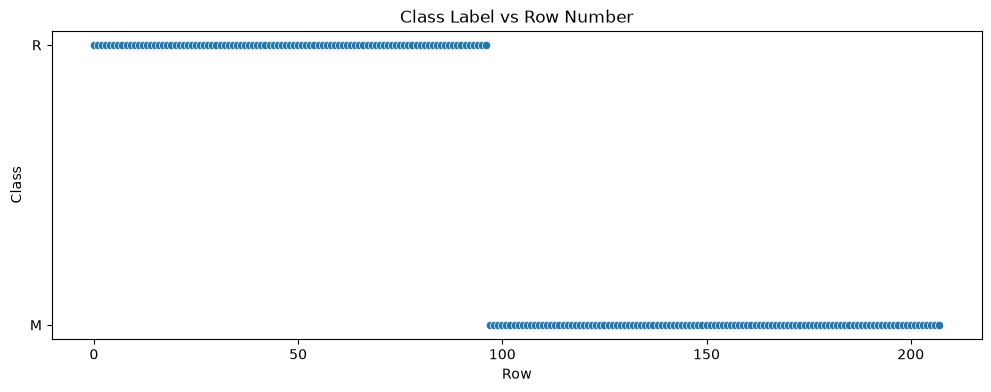

In [18]:
plot_df = pd.DataFrame({
    'Row': np.arange(len(df)),
    'Class': df.iloc[:, 61]
})

plt.figure(figsize=(12,4))

sns.scatterplot(
    data=plot_df,
    x='Row',
    y='Class'
)

plt.title('Class Label vs Row Number')
plt.show()


## Process Labels


### Convert String Labels into Numbers


In [19]:
if debug:
    print(y[0:10])


<ArrowStringArray>
['R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R']
Length: 10, dtype: str


In [20]:
if debug:
    print(y[-10:])


<ArrowStringArray>
['M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M']
Length: 10, dtype: str


In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# R -> 1
# M -> 0


In [22]:
if debug:
    print(y_encoded[0:20])


[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [23]:
if debug:
    print(y_encoded[-20:])


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


## Train / Test Split


In [24]:
# Shuffeling is required because the labels are not in random order


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=0,
    stratify=y
)


In [26]:
if debug:
    print(X_train[0:10])


         0       1       2       3       4       5       6       7       8   \
150  0.0209  0.0278  0.0115  0.0445  0.0427  0.0766  0.1458  0.1430  0.1894   
135  0.0094  0.0611  0.1136  0.1203  0.0403  0.1227  0.2495  0.4566  0.6587   
15   0.0298  0.0615  0.0650  0.0921  0.1615  0.2294  0.2176  0.2033  0.1459   
70   0.0065  0.0122  0.0068  0.0108  0.0217  0.0284  0.0527  0.0575  0.1054   
160  0.0258  0.0433  0.0547  0.0681  0.0784  0.1250  0.1296  0.1729  0.2794   
72   0.0208  0.0186  0.0131  0.0211  0.0610  0.0613  0.0612  0.0506  0.0989   
151  0.0231  0.0315  0.0170  0.0226  0.0410  0.0116  0.0223  0.0805  0.2365   
7    0.0519  0.0548  0.0842  0.0319  0.1158  0.0922  0.1027  0.0613  0.1465   
159  0.0235  0.0220  0.0167  0.0516  0.0746  0.1121  0.1258  0.1717  0.3074   
165  0.0221  0.0065  0.0164  0.0487  0.0519  0.0849  0.0812  0.1833  0.2228   

         9   ...      50      51      52      53      54      55      56  \
150  0.1853  ...  0.0133  0.0096  0.0014  0.0049  0.00

In [27]:
if debug:
    print(y_train[0:10])


[0 0 1 1 0 1 0 1 0 0]


## Scale the Data using StandardScaler


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)


In [29]:
if debug:
    print(X_train_std[0:1])


[[-3.12351518e-01 -3.28847577e-01 -7.82878301e-01 -2.32443029e-01
  -6.10032503e-01 -5.44277232e-01  3.42883844e-01  1.04155773e-01
   1.21039893e-01 -1.68170492e-01 -4.89696344e-01 -7.05246187e-01
  -9.72745050e-01 -9.92762746e-01 -4.20262780e-01 -9.65551030e-02
   1.25828672e-01  1.95199363e-01  3.41111371e-01  7.93973935e-01
   1.18454794e+00  1.43259637e+00  1.05836676e+00  3.25656715e-01
  -4.54805634e-01 -1.57816168e+00 -2.26502326e+00 -2.45867847e+00
  -1.36268071e+00 -8.51678998e-01 -7.31741855e-01  3.26405265e-01
  -2.12631205e-03 -8.90713903e-01 -1.35707502e+00 -4.59704311e-01
   1.96401637e-01  1.94328570e-01 -2.11798275e-01 -7.40784152e-01
  -7.49080428e-01 -1.18006706e+00 -1.30600202e+00 -8.87571065e-01
  -9.24076167e-01 -8.79759956e-01 -8.29318535e-01 -8.33954752e-01
  -1.08245228e+00 -5.76594010e-01 -2.42761910e-01 -3.89582966e-01
  -1.38528054e+00 -8.57063574e-01 -7.65117400e-01 -9.06442258e-01
   2.07022513e-02 -4.64476440e-01 -9.36070378e-01 -1.04815115e+00]]


In [30]:
if debug:
    print(X_test_std[0:1])


[[ 1.05861356  1.57766683  0.41283562 -0.29199466  0.33138062  2.31945015
   0.86730577  0.81045667  0.77812895 -0.6110537   0.23349844  0.18742013
   1.12513001  0.31164029 -0.68259747 -0.53981708 -0.42653045 -1.21288929
  -0.90151563 -0.83235925 -0.36093572  0.31929987  0.28946303  0.05026971
  -0.64750559 -0.67335015 -0.31516124  0.6790003   1.14993617  1.34690642
   2.29237313  2.37696336  1.61589591  1.3896657   1.49207077  0.20495982
  -0.83542187 -0.69625496 -0.92178637 -0.00874659  2.47221397  3.46782251
   2.16342077  1.84042968  3.28050569  3.91266691  2.28300995  0.7983149
  -0.39244628  1.05585394  2.75085422  3.62575067  2.66537302  0.51399946
   0.29709346  0.76958589 -1.0034503   0.45063274 -0.11962493  0.2086729 ]]


## Perform PCA on Variable Number of Components


In [31]:
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

def run_one_pca_model(ncomp, seed):

    pca = PCA(n_components=ncomp)

    X_train_pca = pca.fit_transform(X_train_std)
    X_test_pca = pca.transform(X_test_std)

    model = MLPClassifier(
        hidden_layer_sizes=(100,),
        activation='logistic',
        max_iter=20000,
        alpha=1e-5,
        solver='adam',
        random_state=seed
    )

    model.fit(X_train_pca, y_train)

    predictions = model.predict(X_test_pca)
    acc = accuracy_score(y_test, predictions)

    return ncomp, acc, predictions


### Create Function to Parallelize


In [32]:
from joblib import Parallel, delayed

def run_seed(seed):

    results = Parallel(n_jobs=8, verbose=0)(
        delayed(run_one_pca_model)(ncomp, seed)
        for ncomp in range(1, 61)
    )

    return seed, results


In [33]:
#accuracies = []
#best_accuracy = 0
#best_components = 0
#best_predictions = None

#for ncomp, acc, predictions in results:
#    accuracies.append(acc)

#    if debug:
#        print(f"Components={ncomp:2d} Accuracy={acc:.4f}")

#    if acc > best_accuracy:
#        best_accuracy = acc
#        best_components = ncomp
#        best_predictions = predictions

#print("\nBest Result")
#print(f"Best Components = {best_components}")
#print(f"Best Accuracy   = {best_accuracy:.4f}")


In [34]:
# List of random seeds to test.
# Using a variety of small + larger seeds helps check stability across different data splits.
seeds = [0, 1, 2, 3, 4, 5, 10]

# Container to store the final summary for every seed
all_results = []

print('****** Initiating Paraellel Computation (8 cores) ******')
print()

# === Main loop over seeds ===
for seed in seeds:

    # Call the function that runs all n_components for this particular seed.
    seed, results = run_seed(seed)

    # Initialize variables to track the best configuration for this seed
    best_ncomp = None
    best_acc = 0
    best_predictions = None

    # Iterate through all (n_components, accuracy) pairs returned for this seed
    for ncomp, acc, predictions in results:

        # Keep track of the highest accuracy and its corresponding number of components
        if acc > best_acc:
            best_acc = acc
            best_ncomp = ncomp
            best_predictions = predictions

    # Store a structured record for this seed
    all_results.append(
        {
            "seed": seed,
            "best_ncomp": best_ncomp,
            "best_acc": best_acc,
            "best_predictions": best_predictions,
            "results": results # full list of all (ncomp, acc) pairs
        }
    )

    # Print a nice one-line summary for this seed
    print(
        f"Seed = {seed:3d},  "
        f"Best Components = {best_ncomp:2d}, "
        f"Accuracy = {best_acc:.4f}"
    )

print()
print('***** Parallel Computations Complete ******')


****** Initiating Paraellel Computation (8 cores) ******



Seed =   0,  Best Components = 13, Accuracy = 0.9206


Seed =   1,  Best Components = 16, Accuracy = 0.9365


Seed =   2,  Best Components = 16, Accuracy = 0.9365


Seed =   3,  Best Components = 16, Accuracy = 0.9206


Seed =   4,  Best Components = 17, Accuracy = 0.9365


Seed =   5,  Best Components = 16, Accuracy = 0.9365


Seed =  10,  Best Components = 17, Accuracy = 0.9365

***** Parallel Computations Complete ******


## Find the Best Seed Results


In [35]:
# Find the result with the highest best_acc
best_seed_result = max(
    all_results,
    key=lambda x: x["best_acc"]
)

print()
print(f"Best Seed: {best_seed_result['seed']}")
print(f"Best Number of Compnents: {best_seed_result['best_ncomp']}")
print(f"Best Accuracy: {best_seed_result['best_acc']:.4f}")   



Best Seed: 1
Best Number of Compnents: 16
Best Accuracy: 0.9365


## Plot the Results


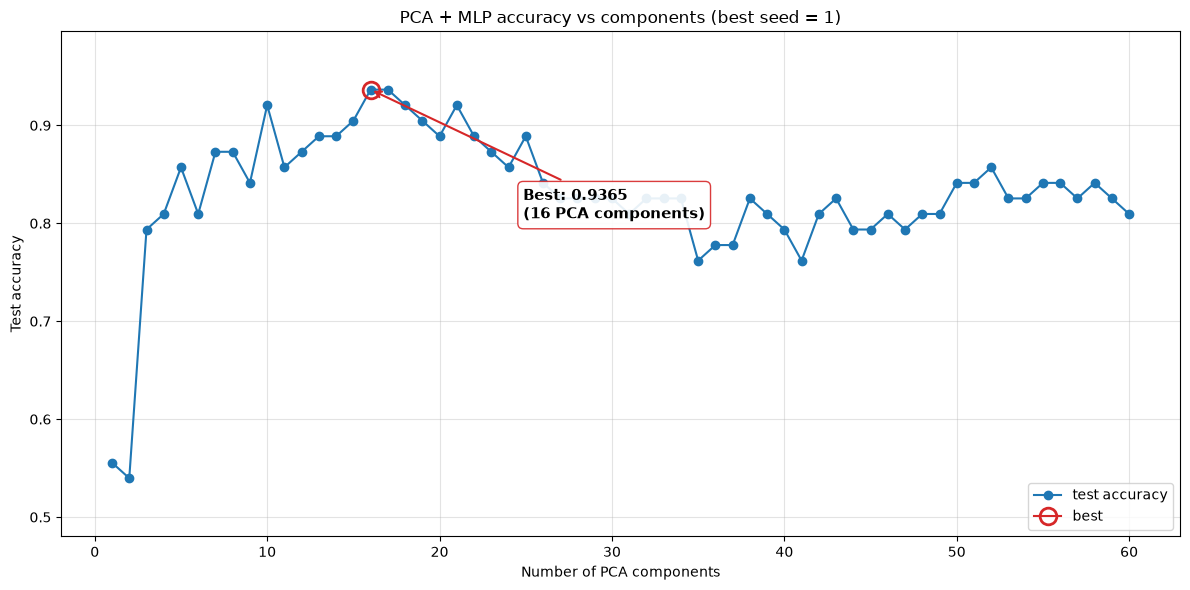

Best seed=1, components=16, accuracy=0.9365


In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Get results for the best seed
results = best_seed_result["results"]

# Extract component counts and accuracies
ncomps = np.array([r[0] for r in results])
accuracies = np.array([r[1] for r in results])

# Find best accuracy
best_idx = np.argmax(accuracies)
best_ncomp = ncomps[best_idx]
best_acc = accuracies[best_idx]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ncomps, accuracies, marker="o", linestyle="-", color="C0", label="test accuracy")
ax.plot(best_ncomp, best_acc, marker="o", markersize=12, color="C3",
        markerfacecolor="none", markeredgewidth=2, label="best")

# Place annotation inside axes using a small offset from the best point
xspan = ncomps.max() - ncomps.min() if ncomps.max() > ncomps.min() else 1
yspan = max(0.05, accuracies.max() - accuracies.min())
xtext = min(best_ncomp + 0.15 * xspan, ncomps.max())
ytext = max(accuracies.min() + 0.05 * yspan, best_acc - 0.25 * yspan)
ax.annotate(
    f"Best: {best_acc:.4f}\n({best_ncomp} PCA components)",
    xy=(best_ncomp, best_acc),
    xytext=(xtext, ytext),
    fontsize=11,
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="C3", lw=1.5),
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="C3", alpha=0.9),
    ha="left",
    va="top",
)
ax.set_xlabel("Number of PCA components")
ax.set_ylabel("Test accuracy")
ax.set_title(f"PCA + MLP accuracy vs components (best seed = {best_seed_result['seed']})")
ax.grid(True, alpha=0.35)
ax.legend(loc="lower right")
# Keep y-limits with padding so annotation stays inside
ymin, ymax = accuracies.min(), accuracies.max()
pad = max(0.02, 0.15 * (ymax - ymin if ymax > ymin else 0.1))
ax.set_ylim(ymin - pad, min(1.0, ymax + pad))
plt.tight_layout()
plt.show()

if debug:
    print(f"Best seed={best_seed_result['seed']}, components={best_ncomp}, accuracy={best_acc:.4f}")


## Create Confusion Matrix


In [37]:
best_predictions = best_seed_result["best_predictions"]


In [38]:
if debug:
    print(best_predictions)


[0 1 0 0 0 0 1 1 1 1 1 1 0 0 1 0 0 1 0 0 0 0 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1
 0 1 0 0 0 1 0 1 0 1 1 0 0 1 0 0 1 0 1 0 1 1 1 0 0 0]


In [39]:
print(len(best_predictions))


63


In [40]:
if debug:
    print(y_test)


[0 1 0 0 1 0 1 1 1 1 1 1 0 0 1 0 0 1 0 0 0 0 1 0 1 1 1 0 0 1 0 0 1 0 0 1 1
 0 1 0 0 0 1 0 1 0 1 1 0 1 1 0 0 1 0 1 0 0 1 1 0 0 0]


In [41]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, best_predictions)

print("\nConfusion Matrix")
print(cm)



Confusion Matrix
[[32  2]
 [ 2 27]]


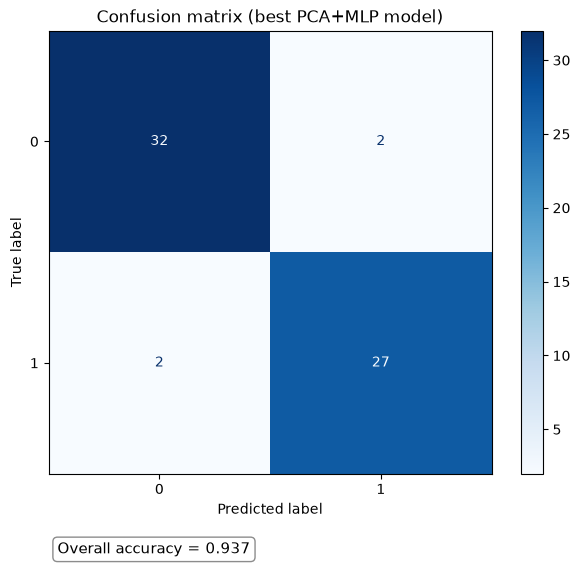

Confusion matrix:
 [[32  2]
 [ 2 27]]
Accuracy from CM: 0.9365


In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, best_predictions)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap="Blues", colorbar=True)
ax.set_title("Confusion matrix (best PCA+MLP model)")
# Annotate overall accuracy inside figure
acc = np.trace(cm) / cm.sum()
ax.text(
    0.02, -0.18,
    f"Overall accuracy = {acc:.3f}",
    transform=ax.transAxes,
    fontsize=11,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.5", alpha=0.9),
)
plt.tight_layout()
plt.show()
if debug:
    print("Confusion matrix:\n", cm)
    print(f"Accuracy from CM: {acc:.4f}")
